In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_093972c579f5afff77400bf23318fb7c'
!kaggle datasets download -d amangarg08/apple-retail-sales-dataset
!unzip -o apple-retail-sales-dataset.zip -d data/
!ls data/

In [ ]:
!pip install pyspark -q

## 1. Clone Team Repository

In [ ]:
!git clone https://github.com/tqwyalshamy740-droid/apple-retail-bigdata.git repo
import sys
sys.path.insert(0, '/content/repo')
sys.path.insert(0, '/content/repo/preprocessing')

## 2. Imports

In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
)
from pyspark.ml.regression import (
    LinearRegression,
    GeneralizedLinearRegression,
    DecisionTreeRegressor,
    RandomForestRegressor,
    GBTRegressor,
    IsotonicRegression
)
from pyspark.ml.evaluation import RegressionEvaluator

## 3. Spark Session

In [ ]:
spark = (SparkSession.builder
         .appName("AppleRetail_Engineer3")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.adaptive.enabled", "true")
         .config("spark.sql.shuffle.partitions", "100")
         .getOrCreate())

spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

## 4. Load Raw Data

In [ ]:
RAW    = "data"
TARGET = "quantity"
SEED   = 42

sales    = spark.read.csv(f"{RAW}/sales.csv",    header=True, inferSchema=True)
products = spark.read.csv(f"{RAW}/products.csv", header=True, inferSchema=True)
stores   = spark.read.csv(f"{RAW}/stores.csv",   header=True, inferSchema=True)
category = spark.read.csv(f"{RAW}/category.csv", header=True, inferSchema=True)

print("sales:",    sales.count())
print("products:", products.count())
print("stores:",   stores.count())
print("category:", category.count())

## 5. Join Tables

In [ ]:
df = (sales
      .join(products, "product_id", "left")
      .join(stores,   "store_id",   "left")
      .join(category, "category_id", "left"))

print("Joined records:", df.count())
print("Columns:", len(df.columns))
df.printSchema()

## 6. Feature Engineering  (replicates Engineer 2 logic)

In [ ]:
from pyspark.sql.functions import (
    to_date, year, month, dayofweek, weekofyear,
    when, col, concat, lit,
    sum as _sum, avg as _avg, count, desc
)
from pyspark.sql.window import Window

df = df.withColumn("sale_date", to_date("sale_date", "dd-MM-yyyy"))

df = (df
      .withColumn("year",        year("sale_date"))
      .withColumn("month",       month("sale_date"))
      .withColumn("day_of_week", dayofweek("sale_date"))
      .withColumn("week_of_year",weekofyear("sale_date")))

df = df.withColumn(
    "is_weekend",
    when(col("day_of_week").isin([1, 7]), 1).otherwise(0)
)

df = df.withColumn(
    "is_bulk_purchase",
    when(col("quantity") >= 5, 1).otherwise(0)
)

df = df.withColumn(
    "high_demand_transaction",
    when(col("quantity") >= 10, 1).otherwise(0)
)

store_features = df.groupBy("store_id").agg(
    _sum("quantity").alias("store_total_sales"),
    _avg("quantity").alias("store_avg_order"),
    count("*").alias("store_transactions")
)
store_w = Window.orderBy(desc("store_total_sales"))
from pyspark.sql.functions import dense_rank
store_features = store_features.withColumn("store_rank", dense_rank().over(store_w))
df = df.join(store_features, "store_id", "left")

product_features = df.groupBy("product_id").agg(
    _sum("quantity").alias("product_total_sales"),
    _avg("quantity").alias("product_avg_sales"),
    count("*").alias("product_frequency")
)
product_w = Window.orderBy(desc("product_total_sales"))
product_features = product_features.withColumn("product_rank", dense_rank().over(product_w))
df = df.join(product_features, "product_id", "left")

df = df.na.fill(0)

print("After feature engineering:", df.count(), "rows |", len(df.columns), "cols")

## 7. Preprocessing  (replicates Engineer 2 pipeline)

In [ ]:
product_indexer = StringIndexer(inputCol="product_id", outputCol="product_index", handleInvalid="keep")
store_indexer   = StringIndexer(inputCol="store_id",   outputCol="store_index",   handleInvalid="keep")

product_encoder = OneHotEncoder(inputCol="product_index", outputCol="product_vec", handleInvalid="keep")
store_encoder   = OneHotEncoder(inputCol="store_index",   outputCol="store_vec",   handleInvalid="keep")

FEATURE_COLS = [
    "product_vec",
    "store_vec",
    "year",
    "month",
    "day_of_week",
    "week_of_year",
    "is_weekend",
    "is_bulk_purchase",
    "high_demand_transaction",
    "store_total_sales",
    "store_avg_order",
    "store_transactions",
    "store_rank",
    "product_total_sales",
    "product_avg_sales",
    "product_frequency",
    "product_rank"
]

assembler = VectorAssembler(inputCols=FEATURE_COLS, outputCol="features", handleInvalid="keep")
scaler    = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=False)

prep_pipeline = Pipeline(stages=[
    product_indexer, store_indexer,
    product_encoder, store_encoder,
    assembler, scaler
])

prep_model = prep_pipeline.fit(df)
df_ml      = prep_model.transform(df)

df_ml = df_ml.select("scaled_features", TARGET).dropna()

print("ML-ready records:", df_ml.count())
df_ml.show(3, truncate=True)

## 8. Train / Test Split

In [ ]:
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=SEED)
train_df.cache()
test_df.cache()
print("train:", train_df.count(), "| test:", test_df.count())

## 9. Train 6 Models

In [11]:
os.makedirs("models", exist_ok=True)

lr = LinearRegression(
    featuresCol="scaled_features", labelCol=TARGET,
    maxIter=100, regParam=0.01, elasticNetParam=0.3
)
lr_model = lr.fit(train_df)
lr_model.save("models/linear_regression")
print("LinearRegression done")

glr = GeneralizedLinearRegression(
    featuresCol="scaled_features", labelCol=TARGET,
    family="gaussian", link="identity",
    maxIter=100, regParam=0.01
)
glr_model = glr.fit(train_df)
glr_model.save("models/generalized_lr")
print("GeneralizedLR done")

dt = DecisionTreeRegressor(
    featuresCol="scaled_features", labelCol=TARGET,
    maxDepth=10, maxBins=256, seed=SEED
)
dt_model = dt.fit(train_df)
dt_model.save("models/decision_tree")
print("DecisionTree done")

rf = RandomForestRegressor(
    featuresCol="scaled_features", labelCol=TARGET,
    numTrees=100, maxDepth=10, maxBins=256,
    minInstancesPerNode=3, seed=SEED
)
rf_model = rf.fit(train_df)
rf_model.save("models/random_forest")
print("RandomForest done")

gbt = GBTRegressor(
    featuresCol="scaled_features", labelCol=TARGET,
    maxIter=80, maxDepth=8, maxBins=256,
    stepSize=0.05, seed=SEED
)
gbt_model = gbt.fit(train_df)
gbt_model.save("models/gbt")
print("GBT done")

iso = IsotonicRegression(
    featuresCol="scaled_features", labelCol=TARGET,
    isotonic=True
)
iso_model = iso.fit(train_df)
iso_model.save("models/isotonic")
print("IsotonicRegression done")

LinearRegression done
GeneralizedLR done
DecisionTree done
RandomForest done
GBT done
IsotonicRegression done


## 10. Evaluate All Models

In [12]:
def evaluate(model, name):
    preds = model.transform(test_df)
    row = {"Model": name}
    for metric in ["rmse", "mae", "r2"]:
        ev = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName=metric)
        row[metric.upper()] = round(ev.evaluate(preds), 4)
    return row

results = [
    evaluate(lr_model,  "LinearRegression"),
    evaluate(glr_model, "GeneralizedLR"),
    evaluate(dt_model,  "DecisionTree"),
    evaluate(rf_model,  "RandomForest"),
    evaluate(gbt_model, "GBT"),
    evaluate(iso_model, "IsotonicRegression"),
]

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df.index += 1
print(results_df.to_string())

best = results_df.iloc[0]
print(f"\nBest Model : {best['Model']}")
print(f"RMSE       : {best['RMSE']}")
print(f"MAE        : {best['MAE']}")
print(f"R2         : {best['R2']}")

                Model    RMSE     MAE      R2
1    LinearRegression  1.2267  1.0038  0.8179
2       GeneralizedLR  1.2269  1.0047  0.8178
3        RandomForest  1.2278  1.0107  0.8176
4                 GBT  1.2286  1.0079  0.8173
5        DecisionTree  1.2289  1.0050  0.8172
6  IsotonicRegression  2.8745  2.5024 -0.0000

Best Model : LinearRegression
RMSE       : 1.2267
MAE        : 1.0038
R2         : 0.8179


## 11. Visualization

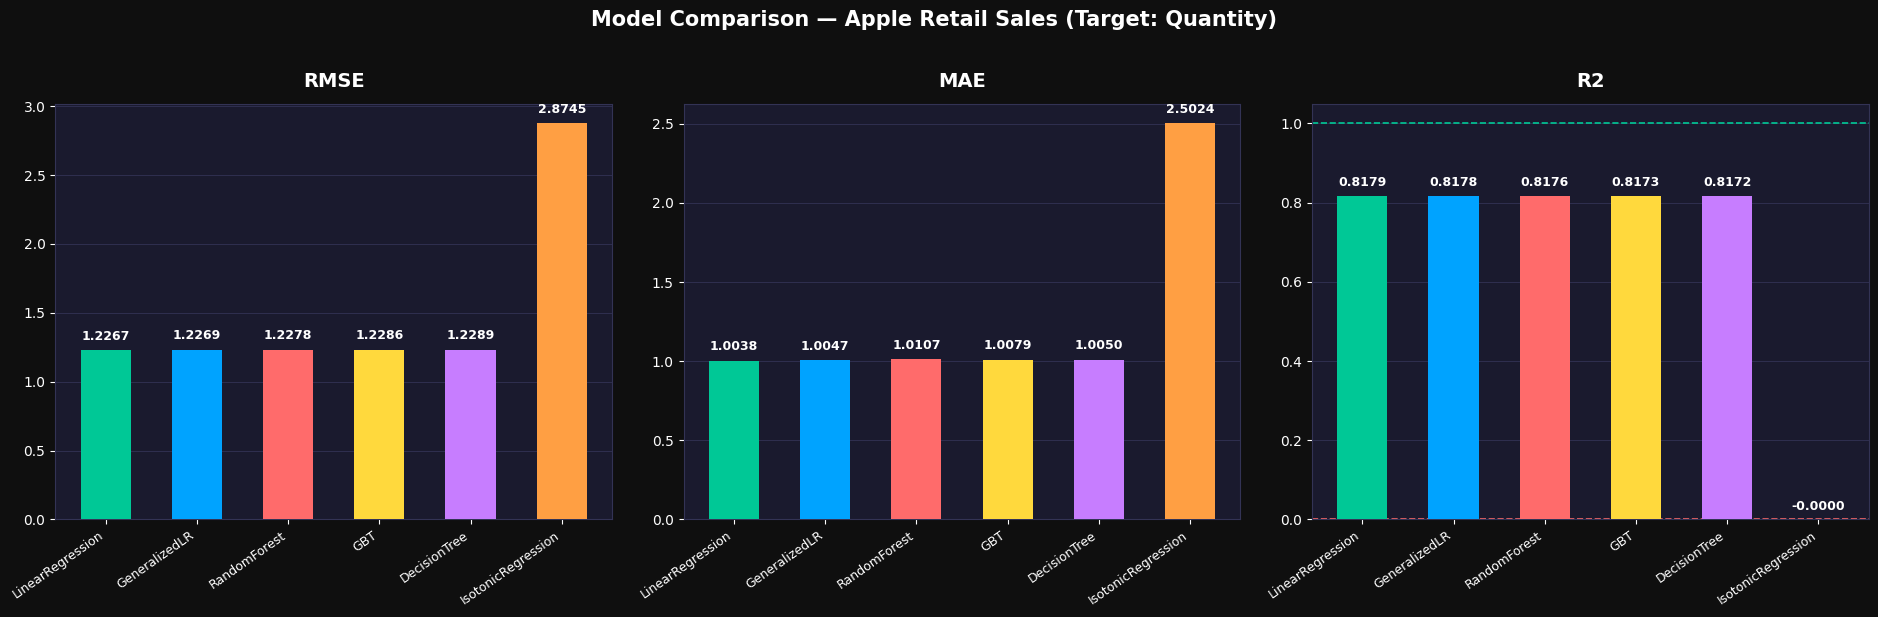

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.patch.set_facecolor("#0f0f0f")

palette = ["#00C896","#00A3FF","#FF6B6B","#FFD93D","#C77DFF","#FF9F43"]
names   = results_df["Model"].tolist()

for ax in axes:
    ax.set_facecolor("#1a1a2e")
    ax.spines[:].set_color("#333355")
    ax.tick_params(colors="white")
    ax.yaxis.label.set_color("white")
    ax.xaxis.label.set_color("white")

for i, metric in enumerate(["RMSE", "MAE", "R2"]):
    vals = results_df[metric].tolist()
    bars = axes[i].bar(names, vals, color=palette, width=0.55, zorder=3)
    axes[i].set_title(metric, color="white", fontsize=14, fontweight="bold", pad=12)
    axes[i].set_xticks(range(len(names)))
    axes[i].set_xticklabels(names, rotation=35, ha="right", fontsize=9, color="white")
    axes[i].grid(axis="y", color="#333355", linewidth=0.6, zorder=0)

    if metric == "R2":
        axes[i].axhline(0, color="#FF6B6B", linewidth=1.2, linestyle="--")
        axes[i].axhline(1, color="#00C896", linewidth=1.2, linestyle="--")

    for bar, val in zip(bars, vals):
        offset = max(abs(v) for v in vals) * 0.02
        ypos   = bar.get_height() + (offset if val >= 0 else -offset * 2)
        axes[i].text(bar.get_x() + bar.get_width()/2, ypos,
                     f"{val:.4f}", ha="center", va="bottom",
                     fontsize=9, color="white", fontweight="bold")

fig.suptitle("Model Comparison — Apple Retail Sales (Target: Quantity)",
             color="white", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("models/model_comparison.png", dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()

## 12. Results Interpretation

In [14]:
for _, row in results_df.iterrows():
    r2 = row["R2"]
    if r2 >= 0.8:
        label = "Excellent"
    elif r2 >= 0.6:
        label = "Good"
    elif r2 >= 0.4:
        label = "Moderate"
    elif r2 >= 0.0:
        label = "Weak"
    else:
        label = "Negative"
    print(f"{row['Model']:<22} RMSE={row['RMSE']:.4f}  MAE={row['MAE']:.4f}  R2={row['R2']:.4f}  [{label}]")

print(f"\nBest: {best['Model']} | RMSE={best['RMSE']} | R2={best['R2']}")
print(f"Explains {max(best['R2']*100, 0):.1f}% of quantity variance.")

LinearRegression       RMSE=1.2267  MAE=1.0038  R2=0.8179  [Excellent]
GeneralizedLR          RMSE=1.2269  MAE=1.0047  R2=0.8178  [Excellent]
RandomForest           RMSE=1.2278  MAE=1.0107  R2=0.8176  [Excellent]
GBT                    RMSE=1.2286  MAE=1.0079  R2=0.8173  [Excellent]
DecisionTree           RMSE=1.2289  MAE=1.0050  R2=0.8172  [Excellent]
IsotonicRegression     RMSE=2.8745  MAE=2.5024  R2=-0.0000  [Weak]

Best: LinearRegression | RMSE=1.2267 | R2=0.8179
Explains 81.8% of quantity variance.


## 13. Save Results

In [15]:
output = {
    "results": results_df.to_dict(orient="records"),
    "best_model": best.to_dict(),
    "feature_cols": FEATURE_COLS,
    "target_col": TARGET,
    "model_paths": {
        "LinearRegression":    "models/linear_regression",
        "GeneralizedLR":       "models/generalized_lr",
        "DecisionTree":        "models/decision_tree",
        "RandomForest":        "models/random_forest",
        "GBT":                 "models/gbt",
        "IsotonicRegression":  "models/isotonic"
    }
}

with open("models/evaluation_results.json", "w") as f:
    json.dump(output, f, indent=4)

print("evaluation_results.json saved")

evaluation_results.json saved


## 14. Copy to Google Drive

In [16]:
from google.colab import drive
import shutil

drive.mount("/content/drive")
drive_path = "/content/drive/MyDrive/apple-retail-bigdata/models"
os.makedirs(drive_path, exist_ok=True)

for folder in ["linear_regression", "generalized_lr", "decision_tree",
               "random_forest", "gbt", "isotonic"]:
    src = f"models/{folder}"
    if os.path.exists(src):
        shutil.copytree(src, f"{drive_path}/{folder}", dirs_exist_ok=True)

shutil.copy("models/evaluation_results.json", f"{drive_path}/evaluation_results.json")
shutil.copy("models/model_comparison.png",    f"{drive_path}/model_comparison.png")

print("All files copied to Google Drive")

ValueError: mount failed